# Lab 3: Federated Learning — Medical Datasets
Comparing FedAvg, SCAFFOLD on Medical and Cardio datasets.

In [29]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

cwd = Path.cwd()
if (cwd / 'runs').exists():
    base_dir = cwd / 'runs'
elif cwd.name == 'runs':
    base_dir = cwd
else:
    base_dir = cwd / 'runs'

plot_dir = base_dir / 'plots' / 'lab_3'
plot_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(plot_dir / name, dpi=200, bbox_inches='tight')
    print(f"Saved plot: {plot_dir / name}")

## 1. Data Loading Helper Functions

In [30]:
def load_global_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the global metrics (like accuracy per round)."""
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv' # Fallback
    
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    return None

def load_locals_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the per-client local metrics."""
    path = run_path / 'locals_metrics.csv'
    return pd.read_csv(path) if path.exists() else None

def load_comm_costs(run_path: Path):
    """Loads communication costs."""
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    """Loads the total run time in seconds."""
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return 0.0
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    return float(row['value'].iloc[0]) if not row.empty else 0.0

def comm_to_mb(comm_df):
    """Converts communication costs from bytes/parameters to Megabytes."""
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / (1024**2)

def get_final_metric(run_path: Path, metric: str):
    """Gets the final-round value of a metric."""
    df = load_global_metrics(Path(run_path))
    if df is not None and metric in df.columns:
        return df[metric].iloc[-1]
    return None

def get_best_metric(run_path: Path, metric: str):
    """Gets the best (max) value of a metric."""
    df = load_global_metrics(Path(run_path))
    if df is not None and metric in df.columns:
        return df[metric].max()
    return None

## 2. Generic Plotting Functions

In [31]:
MODEL_COLORS = {
    'MLP': '#2196F3',
    'LogReg': '#F44336',
}

LINESTYLES = ['-', '--', '-.', ':']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']


def plot_evolution_metric(experiments_dict, metric='accuracy', title='Model Comparison',
                          filename='evolution.png', ylabel=None, mark_every=5):
    """Plots a line chart of a given metric (e.g., accuracy) over communication rounds."""
    plt.figure(figsize=(12, 7))
    cm = plt.get_cmap('tab10')
    
    plotted_any = False
    
    for i, (path, label) in enumerate(experiments_dict.items()):
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            color = cm(i % 10)
            l_style = LINESTYLES[i % len(LINESTYLES)]
            marker = MARKERS[i % len(MARKERS)]
            
            plt.plot(df['round'], df[metric], 
                     color=color, linestyle=l_style, linewidth=2, label=str(label),
                     marker=marker, markersize=4, markevery=mark_every)
            plotted_any = True
        else:
            print(f"\u26a0\ufe0f Warning: Could not load metric '{metric}' for '{label}' at {path}")
            
    if plotted_any:
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Communication Round', fontsize=12)
        plt.ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_fig(filename)
        plt.show()
    else:
        print("No data available to plot.")


def plot_cost_summary(experiments_dict, title='Cost Summary', filename='costs.png'):
    """Plots a dual-axis bar chart comparing Time (seconds) and Comm Costs (MB)."""
    times = []
    comms = []
    valid_labels = []
    
    for path, label in experiments_dict.items():
        p = Path(path)
        if not p.exists():
            print(f"\u26a0\ufe0f Warning: Path not found: {p}")
            continue
            
        times.append(load_run_time(p))
        comms.append(comm_to_mb(load_comm_costs(p)))
        valid_labels.append(str(label))
        
    if not times:
        print("No data to plot for costs.")
        return

    x = np.arange(len(valid_labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(max(10, len(valid_labels) * 1.8), 7))

    # Time (Left Y-Axis)
    color1 = '#E76F51' # Orange/Red
    ax1.set_xlabel('Experiment Configuration', fontsize=12)
    ax1.set_ylabel('Total Time (s)', color=color1, fontsize=12)
    rects1 = ax1.bar(x - width/2, times, width, label='Time (s)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Add time values on top of bars
    for bar in rects1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}s', 
                 ha='center', va='bottom', fontsize=10, color=color1)

    # Communication (Right Y-Axis)
    ax2 = ax1.twinx()  
    color2 = '#2A9D8F'
    ax2.set_ylabel('Total Communication (MB)', color=color2, fontsize=12)  
    rects2 = ax2.bar(x + width/2, comms, width, label='Comm (MB)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    for bar in rects2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', 
                 ha='center', va='bottom', fontsize=10, color=color2)

    ax1.set_xticks(x)
    ax1.set_xticklabels(valid_labels, rotation=45, ha="right")
    plt.title(title, fontsize=14, fontweight='bold')
    fig.tight_layout()  
    save_fig(filename)
    plt.show()


def plot_bar_comparison(experiments_dict, metric='accuracy', title='Comparison',
                        filename='bar.png', ylabel=None, use_final_round=True):
    """Plots a bar chart comparing the final (or best) value of a metric across experiments."""
    values = []
    labels = []

    for path, label in experiments_dict.items():
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            if use_final_round:
                val = df[metric].iloc[-1]
            else:
                val = df[metric].max()
            values.append(val)
            labels.append(str(label))

    if not values:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.5), 6))
    cm = plt.get_cmap('tab10')
    colors = [cm(i % 10) for i in range(len(labels))]
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_utility_vs_cost(experiments_dict, utility_metric='accuracy',
                         title='Utility vs Cost', filename='utility_vs_cost.png'):
    """Scatter plot: accuracy (utility) vs training time (cost)."""
    fig, ax = plt.subplots(figsize=(10, 7))
    cm = plt.get_cmap('tab10')

    for i, (path, label) in enumerate(experiments_dict.items()):
        p = Path(path)
        df = load_global_metrics(p)
        t = load_run_time(p)
        if df is not None and utility_metric in df.columns and t > 0:
            final_val = df[utility_metric].iloc[-1]
            color = cm(i % 10)
            marker = MARKERS[i % len(MARKERS)]
            ax.scatter(t, final_val, color=color, marker=marker, s=200, label=str(label),
                       edgecolors='black', linewidths=0.8, zorder=5)
            # Text annotation removed as per request (relying on legend)
            # ax.annotate(str(label), (t, final_val), textcoords='offset points', xytext=(10, 5), fontsize=9)

    ax.set_xlabel('Training Time (s) \u2014 Cost', fontsize=12)
    ax.set_ylabel(f'{utility_metric.replace("_", " ").title()} \u2014 Utility', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_metric_vs_param(model_data, param_name, metric, title, filename,
                         ylabel=None, use_best=False):
    """
    Generic: plot a metric against a swept parameter for both models side-by-side.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name, entries in model_data.items():
        params = []
        values = []
        for param_val, run_path in sorted(entries, key=lambda x: x[0]):
            p = Path(run_path)
            if use_best:
                val = get_best_metric(p, metric)
            else:
                val = get_final_metric(p, metric)
            if val is not None:
                params.append(param_val)
                values.append(val)

        if params:
            color = MODEL_COLORS.get(model_name, '#666666')
            ax.plot(params, values, color=color, linewidth=2.5, label=model_name,
                    marker='o', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
            for pv, vv in zip(params, values):
                ax.annotate(f'{vv:.4f}', (pv, vv), textcoords='offset points',
                            xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_time_vs_param(model_data, param_name, title, filename):
    """
    Plot training time against a swept parameter for both models.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name, entries in model_data.items():
        params = []
        times = []
        for param_val, run_path in sorted(entries, key=lambda x: x[0]):
            p = Path(run_path)
            t = load_run_time(p)
            if t > 0:
                params.append(param_val)
                times.append(t)

        if params:
            color = MODEL_COLORS.get(model_name, '#666666')
            ax.plot(params, times, color=color, linewidth=2.5, label=model_name,
                    marker='s', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
            for pv, tv in zip(params, times):
                ax.annotate(f'{tv:.1f}s', (pv, tv), textcoords='offset points',
                            xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel('Training Time (s)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_grouped_bars(model_data, param_name, metric, title, filename,
                      ylabel=None, use_best=False):
    """
    Grouped bar chart: one group per param value, bars for each model.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    all_params = sorted(set(
        pv for entries in model_data.values() for pv, _ in entries
    ))
    model_names = list(model_data.keys())
    n_models = len(model_names)
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(all_params) * 2), 6))
    x = np.arange(len(all_params))

    for mi, model_name in enumerate(model_names):
        lookup = {}
        for pv, rp in model_data[model_name]:
            p = Path(rp)
            if use_best:
                val = get_best_metric(p, metric)
            else:
                val = get_final_metric(p, metric)
            if val is not None:
                lookup[pv] = val

        vals = [lookup.get(pv, 0) for pv in all_params]
        offset = (mi - (n_models - 1) / 2) * width
        color = MODEL_COLORS.get(model_name, plt.get_cmap('tab10')(mi))
        bars = ax.bar(x + offset, vals, width * 0.9, label=model_name, color=color,
                       edgecolor='white', linewidth=1)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(p) for p in all_params])
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig(filename)
    plt.show()

## 3. Define the Experiments to Compare

In [32]:
def parse_experiment_name(folder_name: str) -> dict:
    """Parses the folder name to extract experiment parameters."""
    meta = {
        'folder': folder_name,
        'lab': None,
        'dataset': 'med',  # Default
        'distribution': None,
        'mechanism': 'Plain',
        'model': None,
        'noise_mult': 0.0,
        'is_vfl': False,
        'algorithm': None,
    }

    parts = folder_name.split('_')

    # 1. Detect Lab
    if folder_name.startswith('lab_3'):
        meta['lab'] = '3'
    elif folder_name.startswith('lab_vfl'):
        meta['lab'] = 'vfl'
        meta['is_vfl'] = True
        meta['mechanism'] = 'VFL'
        meta['algorithm'] = 'VFL'
    else:
        return None  # Not a lab 3/vfl experiment

    # 2. Detect Distribution (IID/Non-IID)
    if 'non_iid' in folder_name or 'non-iid' in folder_name:
        meta['distribution'] = 'non_iid'
    elif 'iid' in folder_name:
        meta['distribution'] = 'iid'

    # 3. Detect Mechanism (DP / VFL)
    if 'DP' in folder_name or 'dp' in folder_name:
        meta['mechanism'] = 'DP'

    # 4. Detect Model + algorithm hints from folder name
    lower_name = folder_name.lower()
    if 'svm' in lower_name:
        meta['model'] = 'SVM'
    elif 'logreg' in lower_name:
        meta['model'] = 'LogReg'
    elif 'mlp' in lower_name:
        meta['model'] = 'MLP'

    if 'scaffold' in lower_name:
        meta['algorithm'] = 'SCAFFOLD'
    elif 'fedavg' in lower_name or 'fed_avg' in lower_name:
        meta['algorithm'] = 'FedAvg'

    # 5. Detect Dataset specificities
    if 'cardio' in lower_name:
        meta['dataset'] = 'cardio'

    # 6. Extract DP Noise Multiplier (last number)
    if meta['mechanism'] == 'DP':
        try:
            meta['noise_mult'] = float(parts[-1])
        except ValueError:
            pass

    # 7. Fallback algorithm mapping for this lab setup
    # User setup: IID uses FedAvg, Non-IID uses SCAFFOLD.
    if not meta['is_vfl'] and meta['algorithm'] is None:
        if meta['distribution'] == 'non_iid':
            meta['algorithm'] = 'SCAFFOLD'
        elif meta['distribution'] == 'iid':
            meta['algorithm'] = 'FedAvg'

    return meta


def _detect_fairness_tag(run_path: Path) -> str:
    """Returns a suffix tag if fairness metrics (SPD/EOD) are present in the run logs."""
    df = load_global_metrics(run_path)
    if df is None:
        return ''

    cols = set(df.columns)
    has_spd = any(c.startswith('spd_') for c in cols)
    has_eod = any(c.startswith('eod_') for c in cols)

    if has_spd and has_eod:
        return ' +Fair(SPD/EOD)'
    return ''


def load_all_experiments(base_path: Path):
    experiments = []
    if not base_path.exists():
        return experiments

    for p in base_path.iterdir():
        if p.is_dir():
            meta = parse_experiment_name(p.name)
            if meta:
                # FILTER: Remove unknowns
                if meta['model'] is None and not meta['is_vfl']:
                    continue

                meta['path'] = p

                # Create a display label
                label_parts = []
                if meta['is_vfl']:
                    label_parts.append('VFL')
                else:
                    label_parts.append(meta['model'])
                    if meta['distribution'] == 'non_iid':
                        label_parts.append('Non-IID')
                    elif meta['distribution'] == 'iid':
                        label_parts.append('IID')

                    if meta['algorithm']:
                        label_parts.append(f"({meta['algorithm']})")

                    if meta['mechanism'] == 'DP':
                        label_parts.append(f"DP(noise={meta['noise_mult']})")

                base_label = ' '.join([x for x in label_parts if x])

                # Disambiguate fairness-enabled runs from baseline runs
                fairness_tag = _detect_fairness_tag(p)
                meta['label'] = f"{base_label}{fairness_tag}".strip()

                experiments.append(meta)

    return experiments


all_experiments = load_all_experiments(base_dir)
df_experiments = pd.DataFrame(all_experiments)

print(f"Found {len(df_experiments)} experiments.")
if not df_experiments.empty:
    print(df_experiments[['folder', 'label', 'algorithm', 'model', 'distribution', 'mechanism', 'noise_mult']].to_string())


# Helper to get a dict for plotting functions
# Ensures legend labels are unique even when multiple runs share same base metadata.
def get_experiment_dict(df_subset):
    out = {}
    used = {}
    for _, row in df_subset.iterrows():
        label = str(row['label'])
        if label in used:
            used[label] += 1
            label = f"{label} [{row['folder']}]"
        else:
            used[label] = 1
        out[row['path']] = label
    return out

Found 15 experiments.
                                        folder                             label algorithm   model distribution mechanism  noise_mult
0              lab_3_med_experiment_iid_logreg               LogReg IID (FedAvg)    FedAvg  LogReg          iid     Plain         0.0
1                 lab_3_med_experiment_iid_svm                  SVM IID (FedAvg)    FedAvg     SVM          iid     Plain         0.0
2          lab_3_med_experiment_non_iid_logreg         LogReg Non-IID (SCAFFOLD)  SCAFFOLD  LogReg      non_iid     Plain         0.0
3     lab_3_med_experiment_iid_cardio_DP_svm_5    SVM IID (FedAvg) DP(noise=5.0)    FedAvg     SVM          iid        DP         5.0
4     lab_3_med_experiment_iid_cardio_DP_svm_1    SVM IID (FedAvg) DP(noise=1.0)    FedAvg     SVM          iid        DP         1.0
5    lab_3_med_experiment_iid_cardio_DP_svm_10   SVM IID (FedAvg) DP(noise=10.0)    FedAvg     SVM          iid        DP        10.0
6   lab_3_med_experiment_iid_cardio_DP_s

---
## 4. Accuracy & F1 over FL Rounds
In this setup, IID runs correspond to FedAvg and Non-IID runs correspond to SCAFFOLD.

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_LogReg_iid_vs_noniid.png


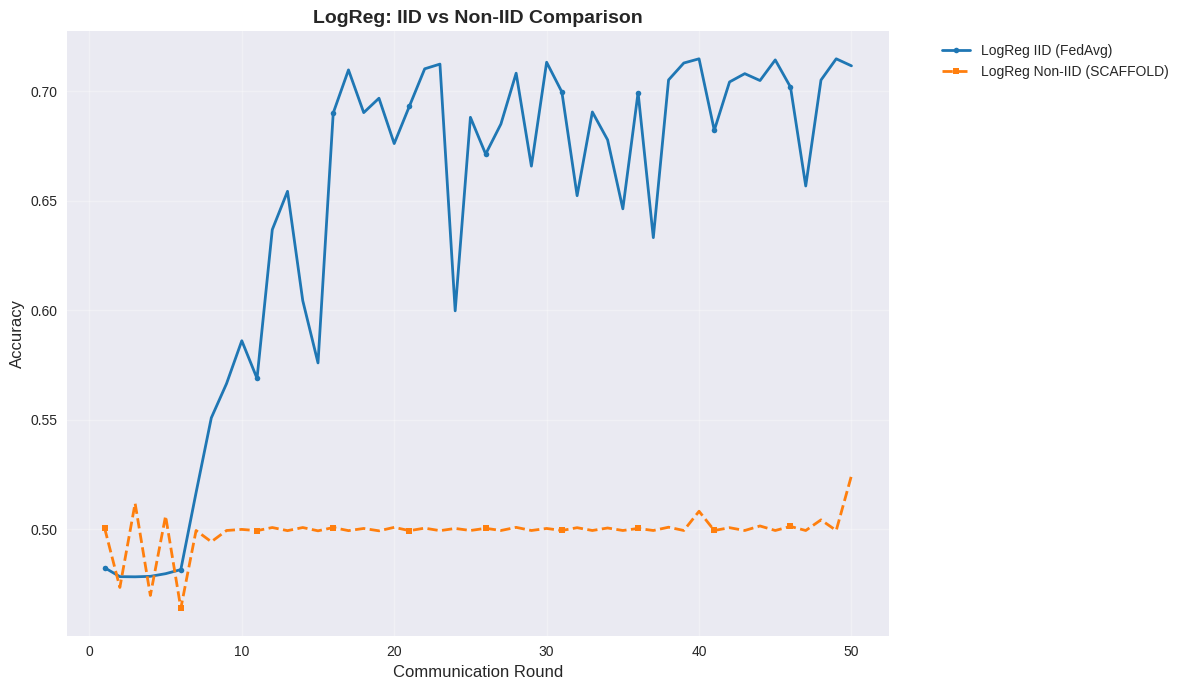

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_MLP_iid_vs_noniid.png


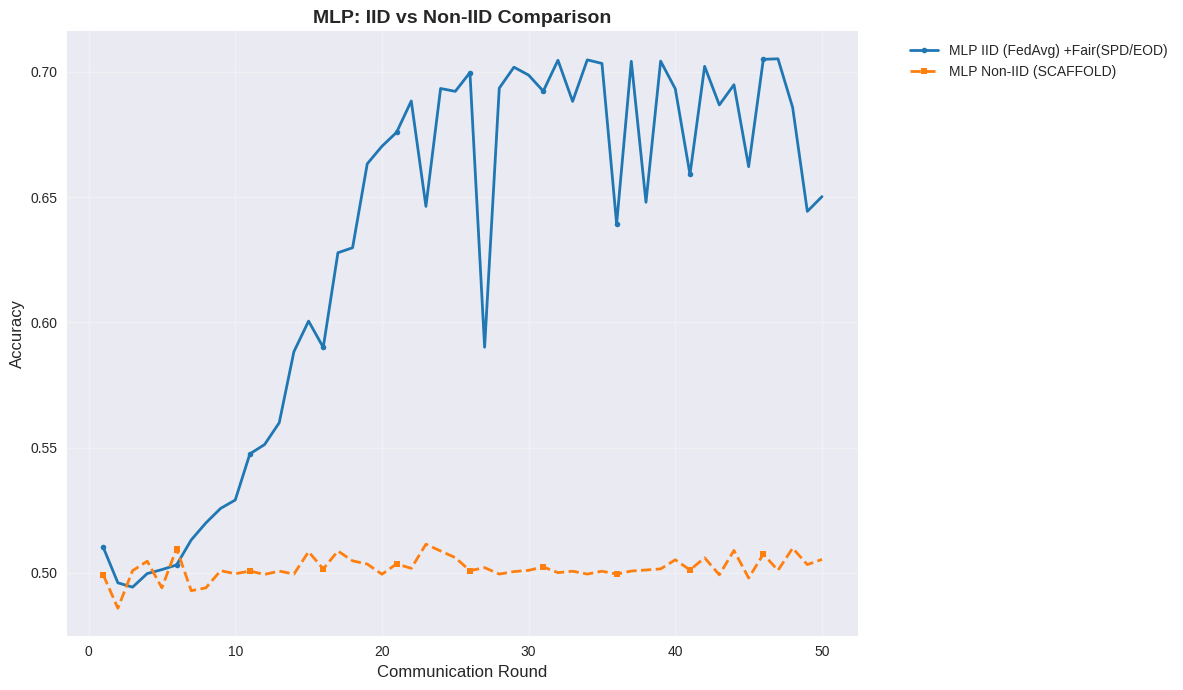

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_SVM_iid_vs_noniid.png


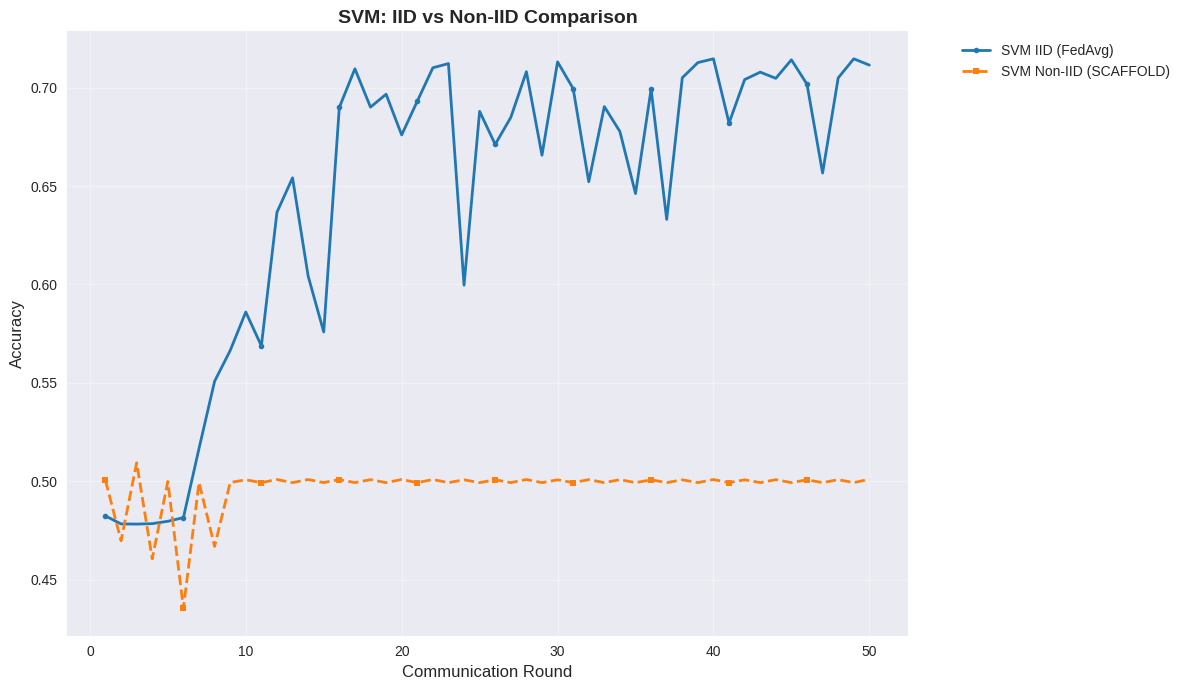

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_all_plain_comparison.png


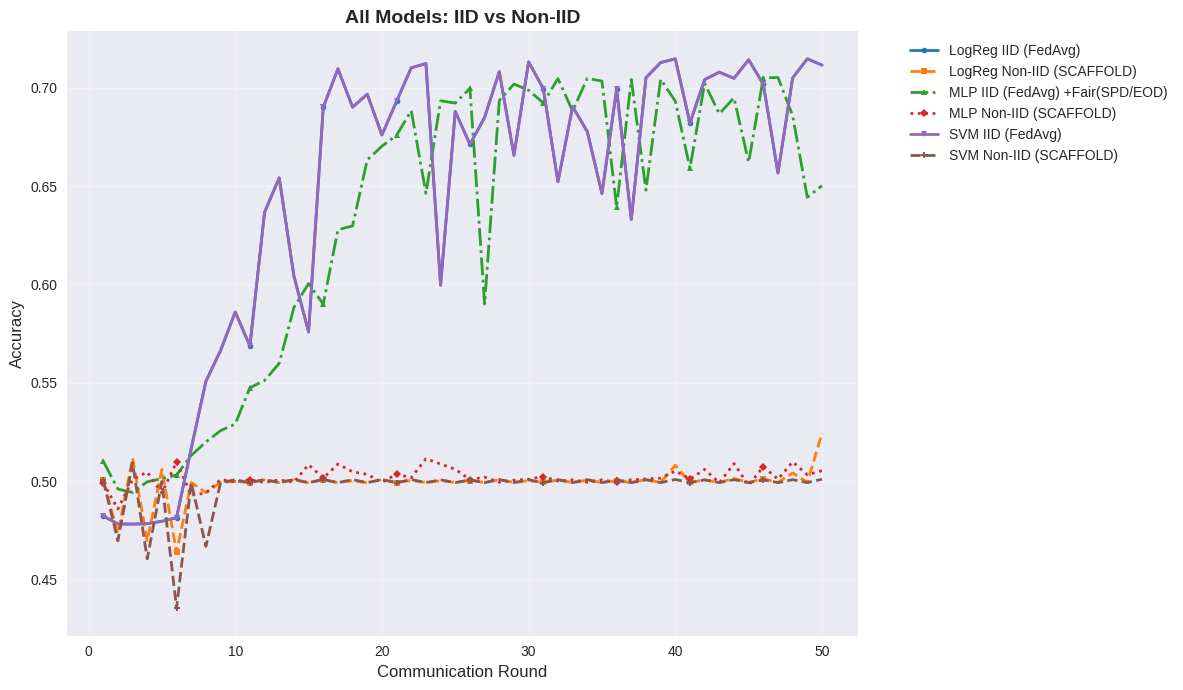

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_vfl_vs_hfl.png


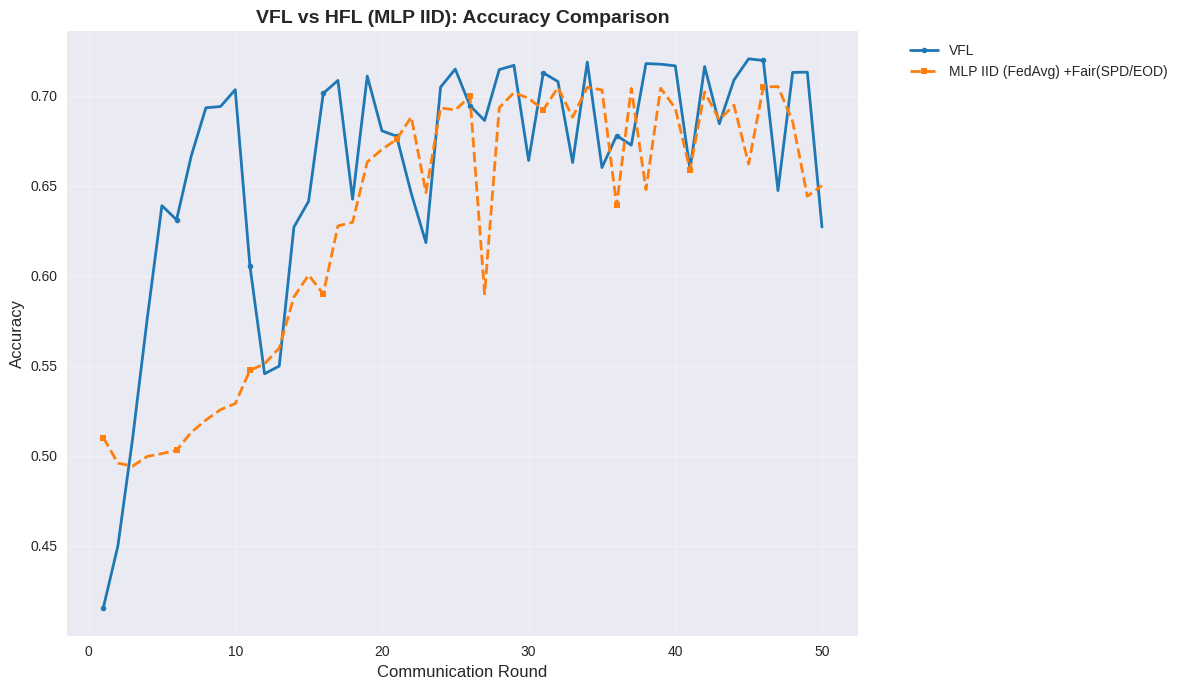

In [33]:
# ── 1. Model Comparison (IID vs Non-IID) ──

# Get all plain experiments (no DP, no VFL)
df_plain = df_experiments[
    (df_experiments['lab'] == '3') & 
    (df_experiments['mechanism'] == 'Plain')
]

if not df_plain.empty:
    models = sorted(df_plain['model'].dropna().unique())
    
    # 1. Plot comparison for each model: IID vs Non-IID
    for model in models:
        model_runs = df_plain[df_plain['model'] == model].copy()
        if model_runs.empty:
            continue

        # Keep a stable and explicit order in legends: IID first, then Non-IID
        order_map = {'iid': 0, 'non_iid': 1}
        model_runs['__dist_order'] = model_runs['distribution'].map(order_map).fillna(2)
        model_runs = model_runs.sort_values(['__dist_order', 'folder'])

        dict_runs = get_experiment_dict(model_runs)

        plot_evolution_metric(dict_runs, metric='accuracy',
                              title=f'{model}: IID vs Non-IID Comparison',
                              filename=f'lab3_{model}_iid_vs_noniid.png', 
                              ylabel='Accuracy')

    # 2. Combined plot (optional, might be crowded)
    # Plot all plain experiments if the set is reasonably small.
    if len(df_plain) <= 12:
        order_map = {'iid': 0, 'non_iid': 1}
        df_plain_sorted = df_plain.copy()
        df_plain_sorted['__dist_order'] = df_plain_sorted['distribution'].map(order_map).fillna(2)
        df_plain_sorted = df_plain_sorted.sort_values(['model', '__dist_order', 'folder'])

        plot_evolution_metric(get_experiment_dict(df_plain_sorted), metric='accuracy',
                              title='All Models: IID vs Non-IID',
                              filename='lab3_all_plain_comparison.png',
                              ylabel='Accuracy')
                              
# ── 2. VFL Experiment ──
df_vfl = df_experiments[df_experiments['lab'] == 'vfl']
dict_vfl = get_experiment_dict(df_vfl)

if dict_vfl:
    # Compare with best IID HFL (e.g., MLP)
    best_hfl = df_plain[(df_plain['model'] == 'MLP') & (df_plain['distribution'] == 'iid')]
    if not best_hfl.empty:
        # Combine dictionaries
        dict_vfl_hfl = {**dict_vfl, **get_experiment_dict(best_hfl)}
        plot_evolution_metric(dict_vfl_hfl, metric='accuracy',
                              title='VFL vs HFL (MLP IID): Accuracy Comparison',
                              filename='lab3_vfl_vs_hfl.png', ylabel='Accuracy')
    else:
         plot_evolution_metric(dict_vfl, metric='accuracy',
                              title='VFL Experiment: Accuracy',
                              filename='lab3_vfl_accuracy.png')


Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_dp_accuracy_vs_noise.png


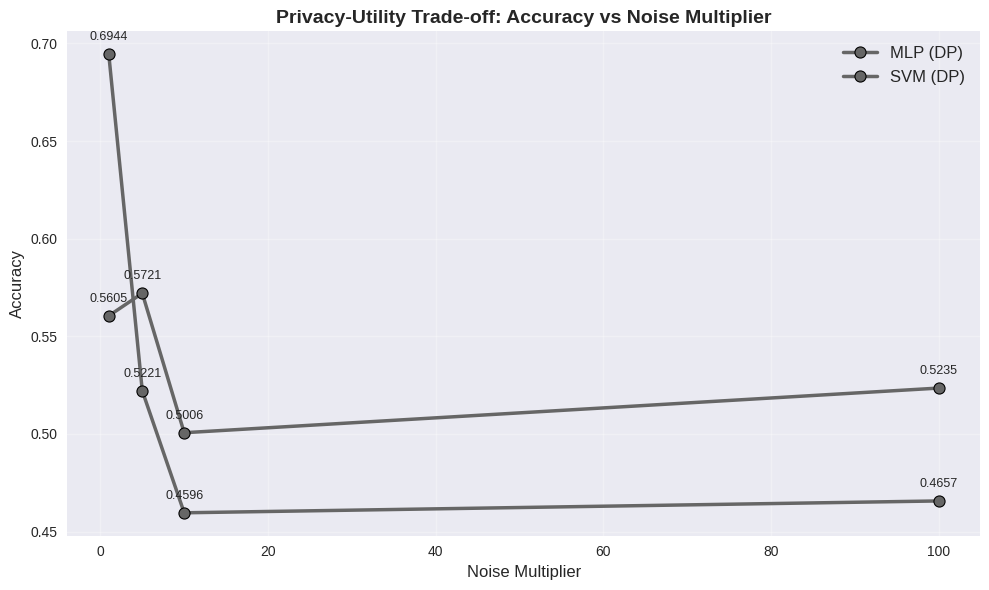

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_dp_micro_f1_vs_noise.png


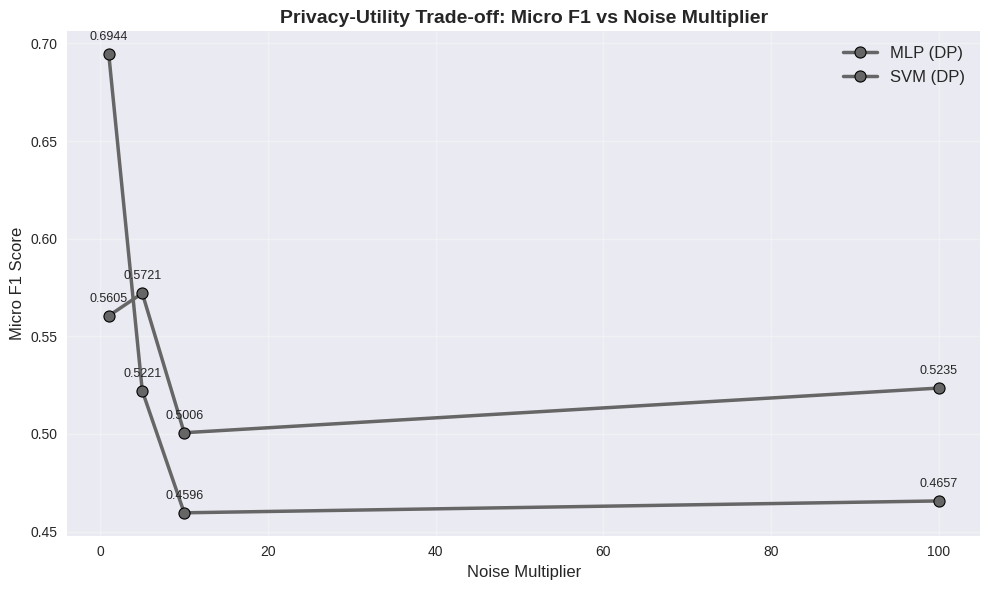

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_dp_svm_evolution.png


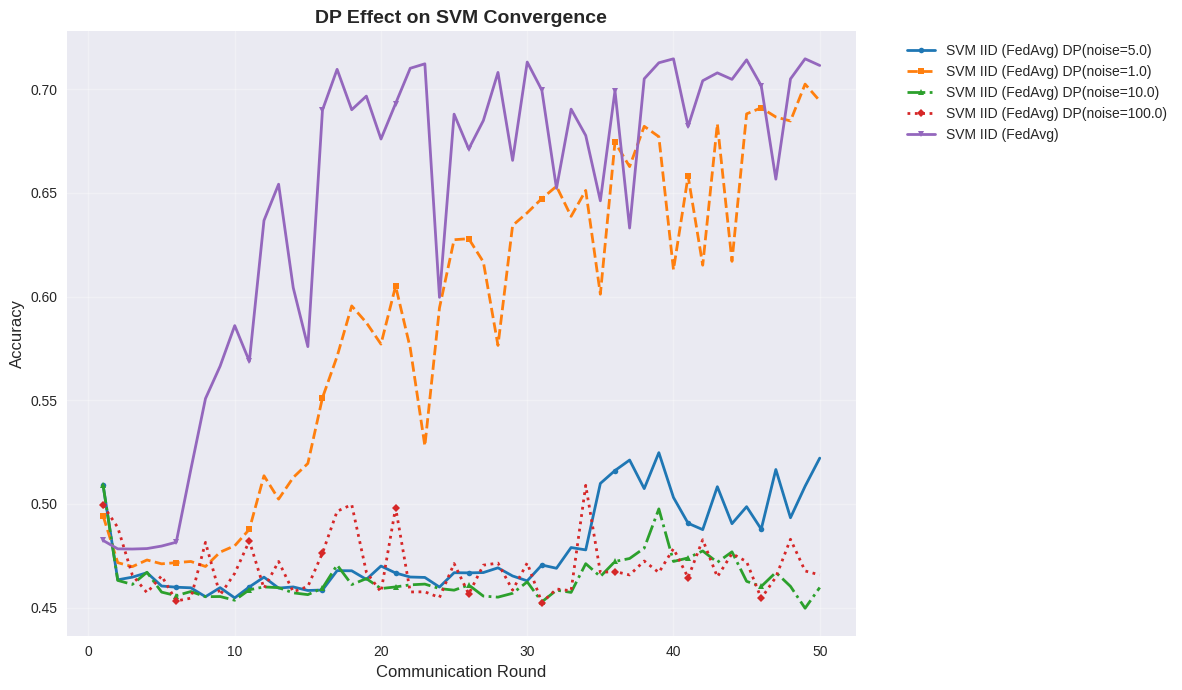

In [34]:
# ── 4. Differential Privacy Experiments ──
df_dp = df_experiments[
    (df_experiments['lab'] == '3') &
    (df_experiments['mechanism'] == 'DP')
]

if not df_dp.empty:
    # Prepare data for plot_metric_vs_param
    # model_data: {model_name: [(noise_mult, run_path), ...]}
    dp_model_data = {}
    
    # Get unique models in DP experiments
    dp_models = sorted(df_dp['model'].dropna().unique())
    
    for model in dp_models:
        model_subset = df_dp[df_dp['model'] == model].copy()

        # Keep only one run per noise value so the noise plots stay clean
        # (expected here: 4 points for SVM noise sweep: 1, 5, 10, 100)
        model_subset = model_subset.sort_values(['noise_mult', 'folder'])
        model_subset = model_subset.drop_duplicates(subset=['noise_mult'], keep='first')

        # Create list of tuples (noise_mult, path)
        entries = [(row['noise_mult'], row['path']) for _, row in model_subset.iterrows()]

        if entries:
            dp_model_data[f"{model} (DP)"] = entries

    if dp_model_data:
        plot_metric_vs_param(dp_model_data, param_name='Noise Multiplier', 
                             metric='accuracy', 
                             title='Privacy-Utility Trade-off: Accuracy vs Noise Multiplier', 
                             filename='lab3_dp_accuracy_vs_noise.png',
                             ylabel='Accuracy')

        plot_metric_vs_param(dp_model_data, param_name='Noise Multiplier',
                             metric='micro_f1',
                             title='Privacy-Utility Trade-off: Micro F1 vs Noise Multiplier',
                             filename='lab3_dp_micro_f1_vs_noise.png',
                             ylabel='Micro F1 Score')
                             
    # Also plot evolution for one model (e.g. SVM) with different noise levels
    example_model = 'SVM'
    svm_dp = df_dp[df_dp['model'] == example_model]
    if not svm_dp.empty:
        dict_svm_dp = get_experiment_dict(svm_dp)
        # Add baseline
        svm_base = df_experiments[
            (df_experiments['lab'] == '3') & (df_experiments['model'] == example_model) & 
            (df_experiments['mechanism'] == 'Plain') & (df_experiments['distribution'] == 'iid')
        ]
        if not svm_base.empty:
            dict_svm_dp.update(get_experiment_dict(svm_base))
            
        plot_evolution_metric(dict_svm_dp, metric='accuracy',
                              title=f'DP Effect on {example_model} Convergence',
                              filename=f'lab3_dp_{example_model.lower()}_evolution.png')


---
## 5. Cost Analysis

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_plain_costs.png


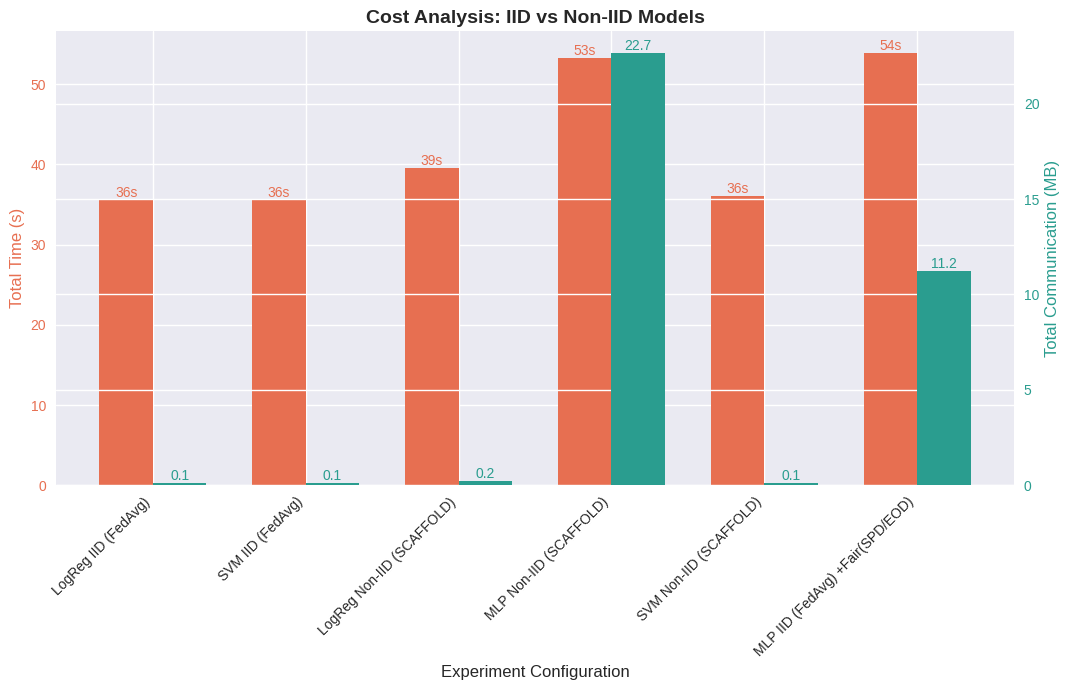

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_dp_svm_costs.png


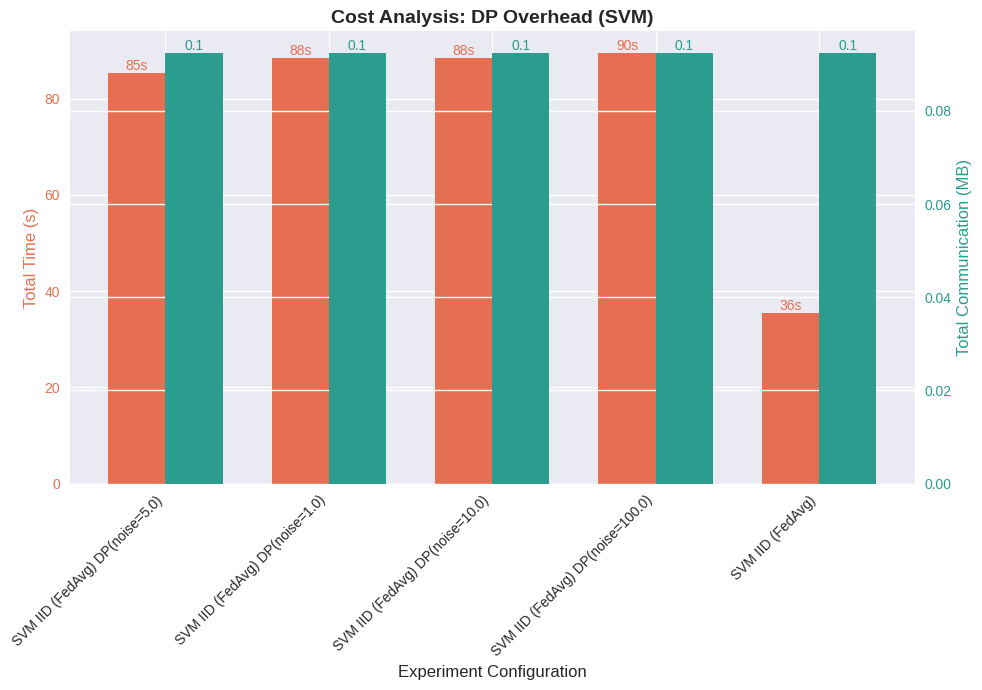

In [25]:
# ── 5. Cost Analysis (Training Time & Communication) ──

# Group 1: Comparison of IID vs Non-IID Costs
if not df_plain.empty:
    dict_plain_costs = get_experiment_dict(df_plain)
    plot_cost_summary(dict_plain_costs, 
                      title='Cost Analysis: IID vs Non-IID Models',
                      filename='lab3_plain_costs.png')

# Group 2: DP Impact on Cost (for one model, e.g. SVM)
svm_dp = df_dp[df_dp['model'] == 'SVM']
if not svm_dp.empty:
    dict_svm_dp_cost = get_experiment_dict(svm_dp)
    # Add baseline
    svm_base = df_experiments[
        (df_experiments['lab'] == '3') & (df_experiments['model'] == 'SVM') & 
        (df_experiments['mechanism'] == 'Plain') & (df_experiments['distribution'] == 'iid')
    ]
    if not svm_base.empty:
        dict_svm_dp_cost.update(get_experiment_dict(svm_base))
        
    plot_cost_summary(dict_svm_dp_cost,
                      title='Cost Analysis: DP Overhead (SVM)',
                      filename='lab3_dp_svm_costs.png')


---
## 6. Utility vs Cost

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_all_utility_vs_cost.png


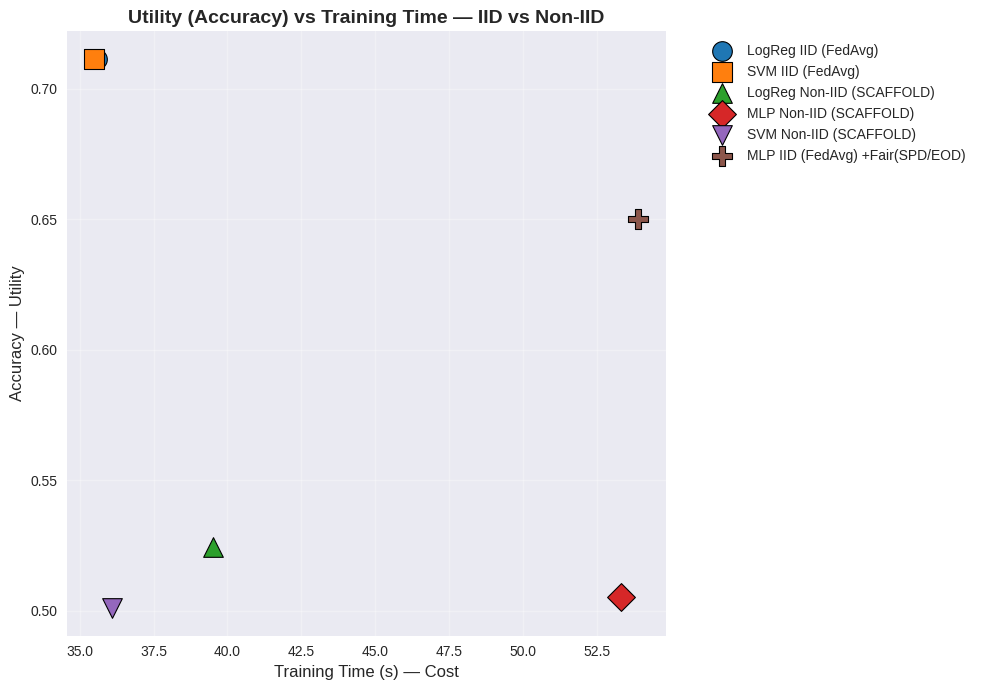

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_dp_utility_vs_cost.png


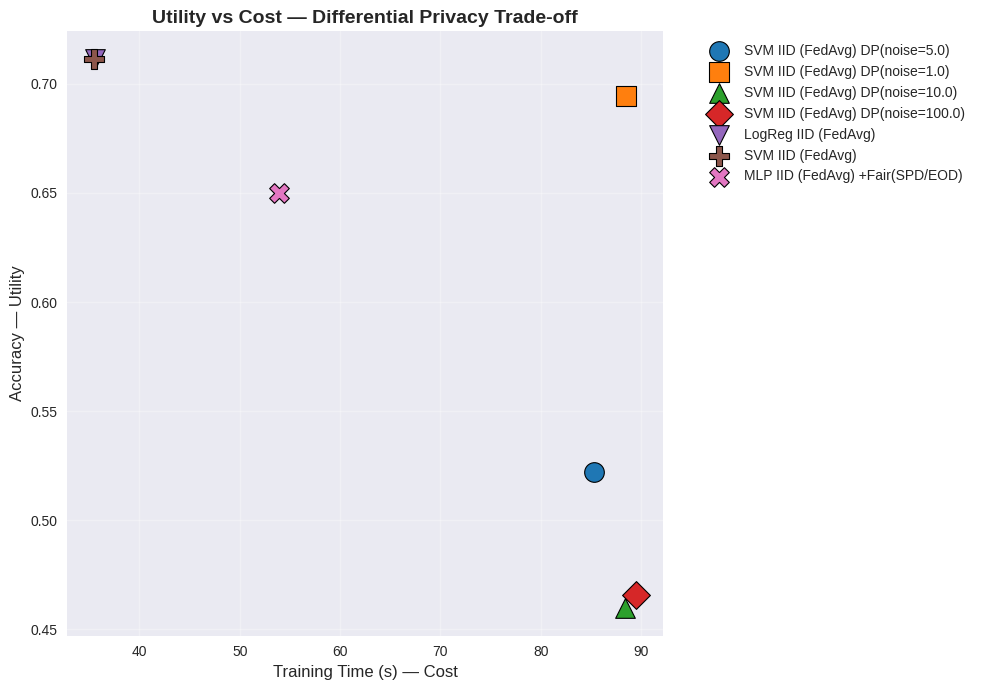

In [26]:
# ── 6. Utility vs Cost ──

# Utility vs Cost: Comparing IID vs Non-IID Models on the same plot
if not df_plain.empty:
    dict_plain_util = get_experiment_dict(df_plain)
    plot_utility_vs_cost(dict_plain_util, utility_metric='accuracy',
                         title='Utility (Accuracy) vs Training Time — IID vs Non-IID',
                         filename='lab3_all_utility_vs_cost.png')

# Utility vs Cost for DP Models (to see if higher privacy costs more time/less utility)
# We can combine all DP experiments for this plot
if not df_dp.empty:
    dict_dp_util = get_experiment_dict(df_dp)
    # Add baseline model(s) for reference
    base_models = df_experiments[
        (df_experiments['lab'] == '3') & (df_experiments['mechanism'] == 'Plain') & 
        (df_experiments['distribution'] == 'iid')
    ]
    if not base_models.empty:
        dict_dp_util.update(get_experiment_dict(base_models))
        
    plot_utility_vs_cost(dict_dp_util, utility_metric='accuracy',
                         title='Utility vs Cost — Differential Privacy Trade-off',
                         filename='lab3_dp_utility_vs_cost.png')


Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_summary_accuracy.png


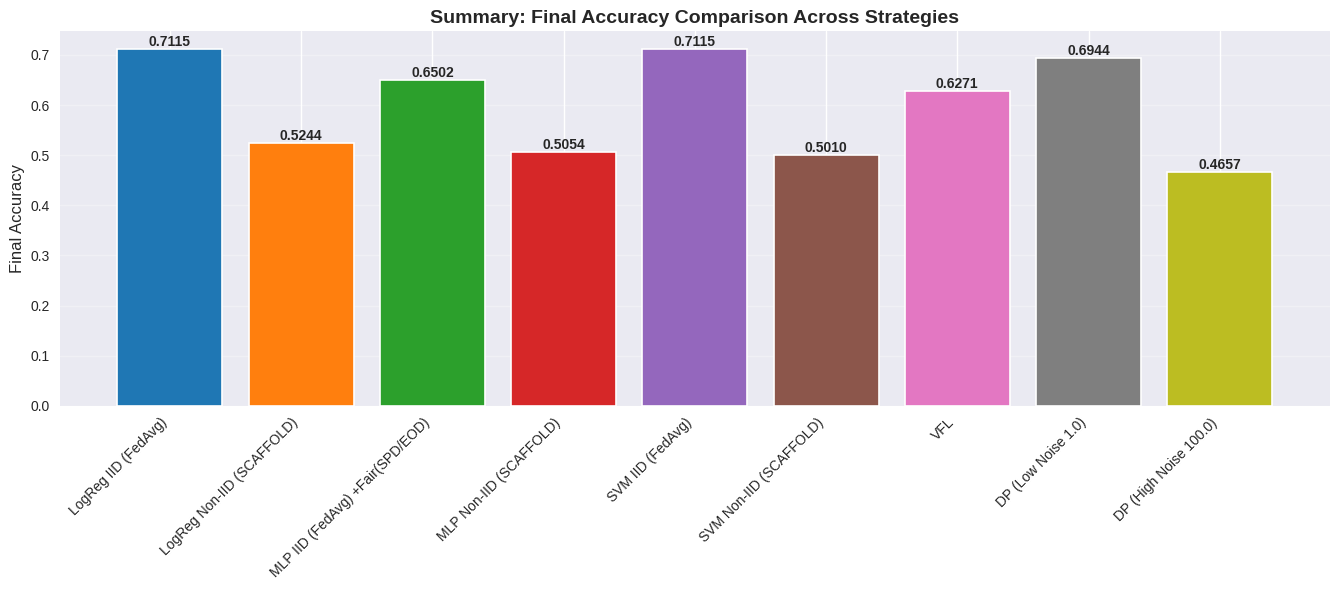

In [27]:
# ── 7. Summary Comparison ──
# Compare the best final accuracy of main strategies

comparison_dict = {}

# 1. Plain Models (Group by Model to compare IID vs Non-IID side-by-side)
if not df_plain.empty:
    models = df_plain['model'].dropna().unique()
    for model in sorted(models):
        # Find IID
        iid_run = df_plain[
            (df_plain['model'] == model) & (df_plain['distribution'] == 'iid')
        ]
        if not iid_run.empty:
            row = iid_run.iloc[0]
            comparison_dict[row['path']] = row['label']
            
        # Find Non-IID
        non_iid_run = df_plain[
            (df_plain['model'] == model) & (df_plain['distribution'] == 'non_iid')
        ]
        if not non_iid_run.empty:
            row = non_iid_run.iloc[0]
            comparison_dict[row['path']] = row['label']

# 2. VFL (if present)
if not df_vfl.empty:
    for _, row in df_vfl.iterrows():
        comparison_dict[row['path']] = "VFL"

# 3. DP (Representative High Noise vs Low Noise)
if not df_dp.empty:
    # Pick min and max noise
    min_noise = df_dp['noise_mult'].min()
    max_noise = df_dp['noise_mult'].max()
    
    dp_min = df_dp[df_dp['noise_mult'] == min_noise].iloc[0]
    dp_max = df_dp[df_dp['noise_mult'] == max_noise].iloc[0]
    
    comparison_dict[dp_min['path']] = f"DP (Low Noise {min_noise})"
    comparison_dict[dp_max['path']] = f"DP (High Noise {max_noise})"

if comparison_dict:
    plot_bar_comparison(comparison_dict, metric='accuracy',
                        title='Summary: Final Accuracy Comparison Across Strategies',
                        filename='lab3_summary_accuracy.png',
                        ylabel='Final Accuracy')


---
## 8. Fairness Plots (SPD / EOD / Group Rates)
This section auto-detects a fairness-enabled run (presence of SPD/EOD columns) and visualizes fairness metrics over rounds.

Using fairness run: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/lab_3_med_experiment_iid_mlp
Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_fairness_gaps_over_rounds.png


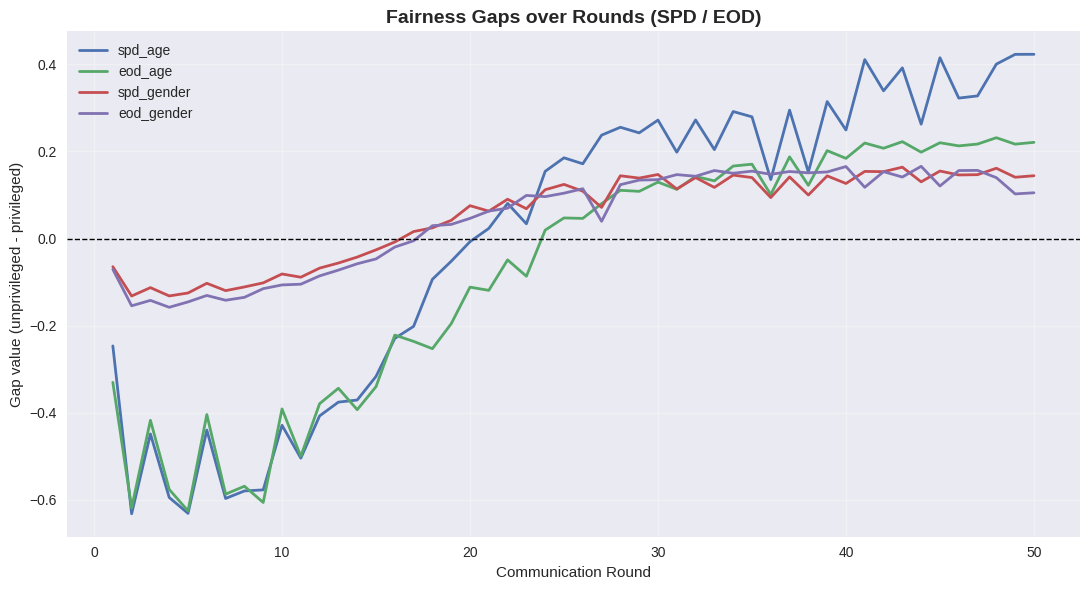

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_group_positive_rates.png


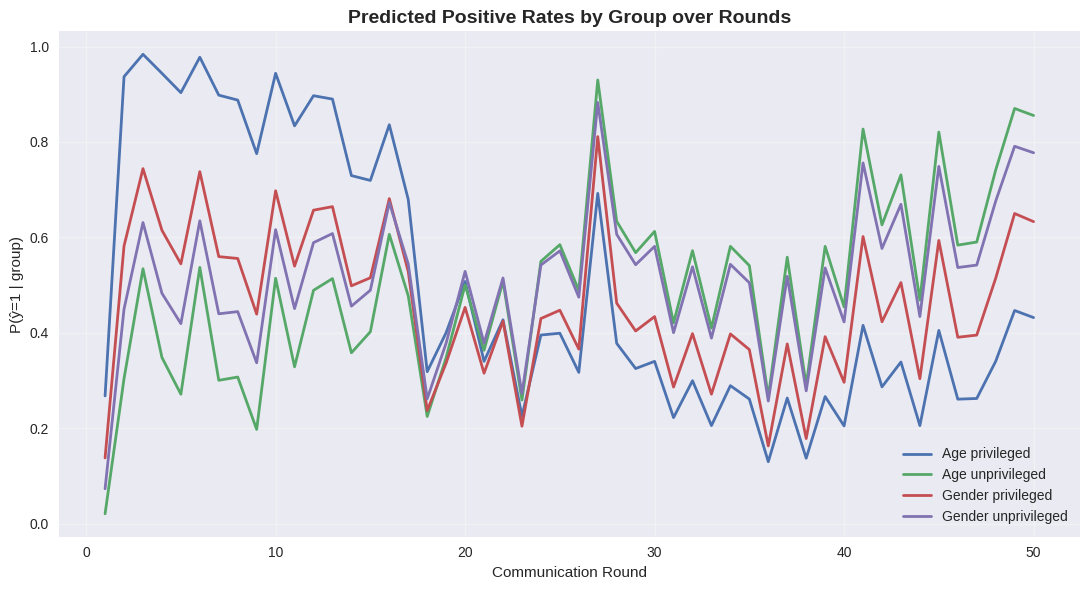

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_group_tpr.png


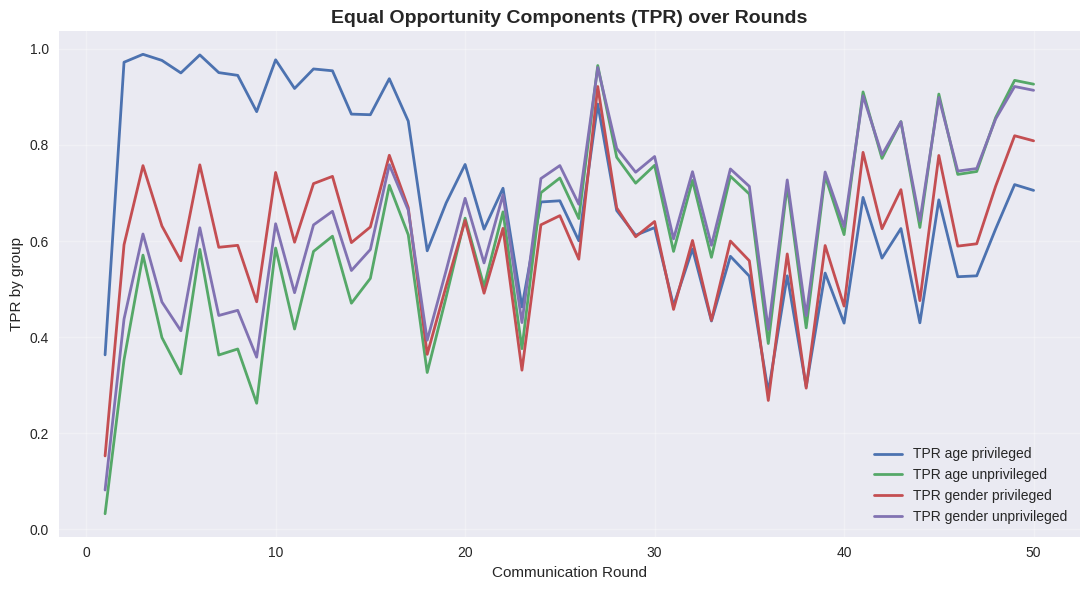

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_3/lab3_fairness_final_round_snapshot.png


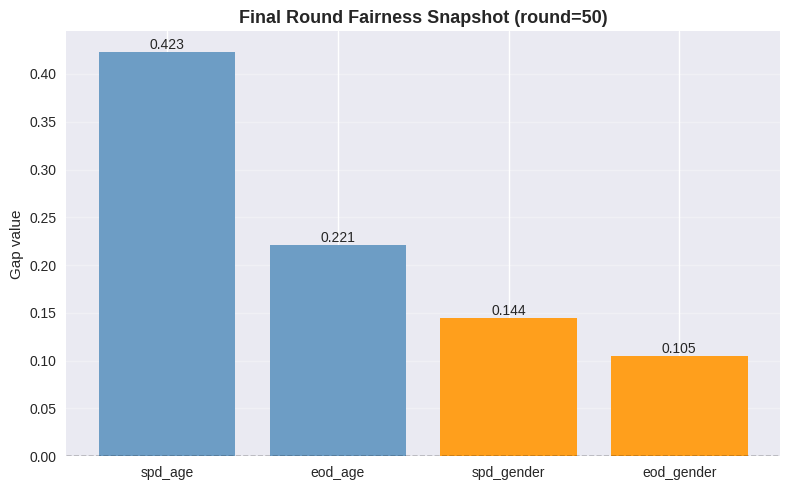

In [28]:
# Auto-detect one fairness-enabled run (has SPD/EOD columns), then plot.

def _find_fairness_run(base_dir: Path):
    preferred_names = [
        'lab_3_med_experiment_SPD_EOD_iid_mlp',
        'python_api_medical_test',
    ]

    # 1) Prefer known run names if present and valid
    for name in preferred_names:
        p = base_dir / name
        if p.exists():
            gdf = load_global_metrics(p)
            if gdf is not None and {'spd_age', 'eod_age', 'spd_gender', 'eod_gender'}.issubset(gdf.columns):
                return p

    # 2) Search all runs for fairness columns
    fairness_cols = {'spd_age', 'eod_age', 'spd_gender', 'eod_gender'}
    for p in sorted(base_dir.iterdir()):
        if not p.is_dir():
            continue
        gdf = load_global_metrics(p)
        if gdf is not None and fairness_cols.issubset(set(gdf.columns)):
            return p

    return None


run_path = _find_fairness_run(base_dir)

if run_path is None:
    print('⚠️ No fairness-enabled run found in:', base_dir)
    print('Expected SPD/EOD columns in global_metrics.csv')
else:
    print('Using fairness run:', run_path)
    fairness_df = load_global_metrics(run_path)

    needed_cols = [
        'round',
        'spd_age', 'eod_age',
        'spd_gender', 'eod_gender',
        'p_pred_pos_age_priv', 'p_pred_pos_age_unpriv',
        'p_pred_pos_gender_priv', 'p_pred_pos_gender_unpriv',
        'tpr_age_priv', 'tpr_age_unpriv',
        'tpr_gender_priv', 'tpr_gender_unpriv'
    ]
    available = [c for c in needed_cols if fairness_df is not None and c in fairness_df.columns]
    missing = [c for c in needed_cols if c not in available]

    if fairness_df is None or 'round' not in fairness_df.columns:
        print('⚠️ No global_metrics.csv with round column found.')
    else:
        if missing:
            print('⚠️ Missing columns:', missing)

        # 1) Fairness gaps over rounds (SPD, EOD)
        gap_cols = [c for c in ['spd_age', 'eod_age', 'spd_gender', 'eod_gender'] if c in fairness_df.columns]
        if gap_cols:
            plt.figure(figsize=(11, 6))
            for col in gap_cols:
                plt.plot(fairness_df['round'], fairness_df[col], linewidth=2, label=col)
            plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
            plt.title('Fairness Gaps over Rounds (SPD / EOD)', fontsize=14, fontweight='bold')
            plt.xlabel('Communication Round')
            plt.ylabel('Gap value (unprivileged - privileged)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            save_fig('lab3_fairness_gaps_over_rounds.png')
            plt.show()

        # 2) Group positive prediction rates over rounds
        rate_cols = [
            ('p_pred_pos_age_priv', 'Age privileged'),
            ('p_pred_pos_age_unpriv', 'Age unprivileged'),
            ('p_pred_pos_gender_priv', 'Gender privileged'),
            ('p_pred_pos_gender_unpriv', 'Gender unprivileged'),
        ]
        present_rate_cols = [(c, l) for c, l in rate_cols if c in fairness_df.columns]
        if present_rate_cols:
            plt.figure(figsize=(11, 6))
            for col, label in present_rate_cols:
                plt.plot(fairness_df['round'], fairness_df[col], linewidth=2, label=label)
            plt.title('Predicted Positive Rates by Group over Rounds', fontsize=14, fontweight='bold')
            plt.xlabel('Communication Round')
            plt.ylabel('P(ŷ=1 | group)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            save_fig('lab3_group_positive_rates.png')
            plt.show()

        # 3) Group TPR over rounds
        tpr_cols = [
            ('tpr_age_priv', 'TPR age privileged'),
            ('tpr_age_unpriv', 'TPR age unprivileged'),
            ('tpr_gender_priv', 'TPR gender privileged'),
            ('tpr_gender_unpriv', 'TPR gender unprivileged'),
        ]
        present_tpr_cols = [(c, l) for c, l in tpr_cols if c in fairness_df.columns]
        if present_tpr_cols:
            plt.figure(figsize=(11, 6))
            for col, label in present_tpr_cols:
                plt.plot(fairness_df['round'], fairness_df[col], linewidth=2, label=label)
            plt.title('Equal Opportunity Components (TPR) over Rounds', fontsize=14, fontweight='bold')
            plt.xlabel('Communication Round')
            plt.ylabel('TPR by group')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            save_fig('lab3_group_tpr.png')
            plt.show()

        # 4) Final-round fairness snapshot
        snapshot_metrics = [m for m in ['spd_age', 'eod_age', 'spd_gender', 'eod_gender'] if m in fairness_df.columns]
        if snapshot_metrics:
            final_row = fairness_df.iloc[-1]
            vals = [float(final_row[m]) for m in snapshot_metrics]
            plt.figure(figsize=(8, 5))
            bars = plt.bar(snapshot_metrics, vals, color=['#6D9DC5', '#6D9DC5', '#FF9F1C', '#FF9F1C'])
            plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
            plt.title(f'Final Round Fairness Snapshot (round={int(final_row["round"])})', fontsize=13, fontweight='bold')
            plt.ylabel('Gap value')
            plt.grid(True, axis='y', alpha=0.3)
            for b, v in zip(bars, vals):
                plt.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top')
            plt.tight_layout()
            save_fig('lab3_fairness_final_round_snapshot.png')
            plt.show()

---
## 9. Requirement Coverage Check (Lab 3)
Quick audit table for the requested items (dataset, FL design, heterogeneity, privacy, fairness, cost, DP, VFL).

### Requirement Coverage Check (Lab 3)

| Requirement | Status | Notebook Evidence |
|---|---|---|
| Choose a medical dataset | YES | Lab 3 experiments parsed (medical/cardio naming). |
| Design the FL system (FedAvg + SCAFFOLD) | YES | Algorithm mapping included; IID → FedAvg and Non-IID → SCAFFOLD. |
| Handle client heterogeneity (IID / Non-IID) | YES | IID/Non-IID parsing and comparison plots are provided. |
| Include privacy-preserving mechanism | YES | DP runs are detected and compared when present. |
| Measure quality + fairness + cost metrics | YES | Accuracy/F1, SPD/EOD (+group rates), communication and runtime analyses are included. |
| Sensitive attributes coverage | YES | Two sensitive features are covered: age and gender. |
| DP noise sweep comparison | YES | Noise-vs-performance comparison is included in the DP section. |
| VFL design & comparison | YES | VFL run detection and VFL vs HFL comparison are included when available. |

**Notes**
- SPD here uses prediction-rate gap across groups (demographic parity style).
- EOD here uses TPR gap across groups.
- For age, groups are thresholded (privileged vs unprivileged), not one metric per exact age value.